In [6]:
import kagglehub
import os
import shutil

#Датасет про учеников и различные факторы. Целевая переменная - оценка за экзамен. В нем 6607 строк и 20 столбцов. 
cache_path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

csv_filename = [f for f in os.listdir(cache_path) if f.endswith('.csv')][0]
source_file = os.path.join(cache_path, csv_filename)

local_file_name = "data2.csv"
shutil.copy(source_file, local_file_name)

'data2.csv'

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
import numpy as np

df = pd.read_csv("data2.csv")

#Пропуски и очистка

#Удаляем строки с пропусками, тк в зависимости от уровня образования родителей, может быть разное отношение к учебе в семье, следовательно, может быть разная успеваемость учеников.
df = df.dropna(subset=["Parental_Education_Level"])

#Тк расстояние до дома - это слово, то оцифруем этот столбец, а затем используем медиану (Можно сразу было использовать моду)
distance_mapping = {"Near": 1, "Moderate": 2, "Far": 3}
df["Distance_Numeric"] = df["Distance_from_Home"].map(distance_mapping)
median_distance = df['Distance_Numeric'].median()
df['Distance_Numeric'] = df['Distance_Numeric'].fillna(median_distance)
#Исходя из distance_numeric, заполняем пропуски в distance_from_home
distance_reverse_mapping = {1 : "Near", 2: "Moderate", 3: "Far"}
df["Distance_from_Home"] = df["Distance_Numeric"].map(distance_reverse_mapping)
df.drop('Distance_Numeric', axis=1, inplace=True)

#Teacher_Quality заполняем модой, тк лучше всего присвоить наиболее часто встречающееся значение
teacher_quality_mode = df["Teacher_Quality"].mode()[0]
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(teacher_quality_mode)

#Кодируем категориальные признаки
df['Parental_Involvement_Enc'] = df['Parental_Involvement'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Access_to_Resources_Enc'] = df['Access_to_Resources'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Motivation_Level_Enc'] = df['Motivation_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Family_Income_Enc'] = df['Family_Income'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Teacher_Quality_Enc'] = df['Teacher_Quality'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Peer_Influence_Enc'] = df['Peer_Influence'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
df['Parental_Education_Level_Enc'] = df['Parental_Education_Level'].map({'High School': 0, 'College': 1, 'Postgraduate': 2})
df['Distance_from_Home_Enc'] = df['Distance_from_Home'].map({'Near': 0, 'Moderate': 1, 'Far': 2})
df = pd.get_dummies(df, columns=['Gender', 'School_Type', 'Learning_Disabilities', 
                                 'Extracurricular_Activities', 'Internet_Access'], drop_first=True)
df.drop(['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income',
         'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home'], axis=1, inplace=True)

df.to_csv("data2after.csv", index=False)

X = df.drop(['Exam_Score'], axis=1)
y = df['Exam_Score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_neighbors_list = [3, 5, 7, 10, 20]
weights_list = ['uniform', 'distance']
metrics_list = ['euclidean', 'manhattan', 'minkowski'] 

best_mae = float('inf')
best_params = {}

param_grid = {
    'n_neighbors' : n_neighbors_list,
    'weights' : weights_list,
    'metric' : metrics_list
    }

grid_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=5, 
    scoring='neg_mean_absolute_error', 
)    

grid_search.fit(X_train, y_train)

print("-" * 30)
final_acc = grid_search.best_estimator_.score(X_test, y_test)
best_knn = grid_search.best_estimator_
y_pred = cross_val_predict(best_knn, X_test, y_test, cv=5)
print(y_pred)
print(" \n")
print(y_test)

print(f"Минимальная ошибка (MAE): {final_acc:.4f}")



            

------------------------------
[66.86499147 71.04138023 66.02508434 ... 67.17877786 67.0035725
 68.55810221]
 

6016    66
5707    72
1021    67
1392    69
2748    71
        ..
6459    65
4620    69
5427    67
1602    68
5075    71
Name: Exam_Score, Length: 1304, dtype: int64
Минимальная ошибка (MAE): 0.5466


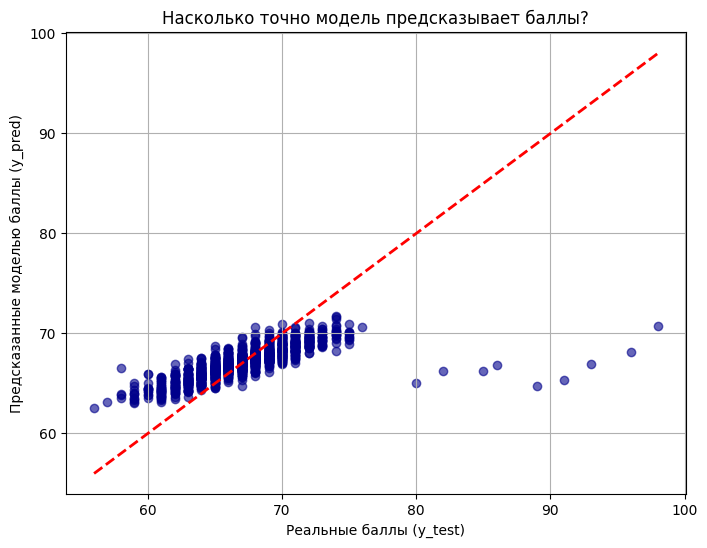

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Реальные баллы (y_test)')
plt.ylabel('Предсказанные моделью баллы (y_pred)')
plt.title('Насколько точно модель предсказывает баллы?')
plt.grid(True)
plt.show()